In [16]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
drive.mount('/content/drive')

STAR_SCHEMA_DIR = '/content/drive/MyDrive/My Project/E-Commerce Data Modeling & Customer Lifetime Value Analytics/data/star_schema'
MODEL_OUTPUT_DIR = '/content/drive/MyDrive/My Project/E-Commerce Data Modeling & Customer Lifetime Value Analytics/data/model'

Mounted at /content/drive


In [3]:
Fact_Orders = pd.read_csv(f'{STAR_SCHEMA_DIR}/Fact_Orders.csv')
Dim_Customer = pd.read_csv(f'{STAR_SCHEMA_DIR}/Dim_Customer.csv')
Dim_Product = pd.read_csv(f'{STAR_SCHEMA_DIR}/Dim_Product.csv')

In [4]:
# Chuyển đổi định dạng ngày
Fact_Orders['order_date'] = pd.to_datetime(Fact_Orders['order_date_key'].astype(str), format='%Y%m%d')

df_analytics = Fact_Orders.merge(Dim_Customer[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='inner')

In [5]:
max_date = df_analytics['order_date'].max() + pd.Timedelta(days=1)

customer_rfm = df_analytics.groupby('customer_unique_id').agg(
    Last_Purchase_Date=('order_date', 'max'),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum'),
    Freight_Spent=('freight_value', 'sum')
).reset_index()

customer_rfm['Recency'] = (max_date - customer_rfm['Last_Purchase_Date']).dt.days
customer_rfm['Historical_CLV'] = customer_rfm['Monetary'] + customer_rfm['Freight_Spent']

customer_rfm['R_Score'] = pd.qcut(customer_rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)
customer_rfm['M_Score'] = pd.qcut(customer_rfm['Historical_CLV'], q=5, labels=False, duplicates='drop') + 1

customer_rfm['F_Score'] = np.where(customer_rfm['Frequency'] == 1, 1, 5)

In [6]:
def assign_segment(row):
    if row['Frequency'] == 1:
        if row['M_Score'] >= 4:
            return 'One-Time Buyer (High Value)'
        elif row['M_Score'] == 3:
            return 'One-Time Buyer (Medium Value)'
        else:
            return 'One-Time Buyer (Low Value)'
    else:
        if row['M_Score'] >= 4:
            return 'Repeat Customer (High Value)'
        else:
            return 'Repeat Customer (Core Value)'

customer_rfm['segment_label'] = customer_rfm.apply(assign_segment, axis=1)

print(f"Phân bố các phân khúc khách hàng:\n{customer_rfm['segment_label'].value_counts()}")

Phân bố các phân khúc khách hàng:
segment_label
One-Time Buyer (Low Value)       37981
One-Time Buyer (High Value)      35848
One-Time Buyer (Medium Value)    18678
Repeat Customer (High Value)      2317
Repeat Customer (Core Value)       596
Name: count, dtype: int64


In [7]:
# Gom nhóm theo order_id trước để tính tổng giá trị của nguyên 1 đơn hàng (thay vì 1 item)
order_level_data = df_analytics.groupby(['customer_unique_id', 'order_id']).agg(
    order_date=('order_date', 'first'),
    first_order_value=('payment_value', 'sum'),
    first_freight_value=('freight_value', 'sum'),
    review_score=('review_score', 'first'),
    customer_state=('customer_state', 'first'),
    product_id=('product_id', 'first') # Đại diện 1 sản phẩm cho đơn
).reset_index()

# Lấy đơn hàng đầu tiên
order_level_data = order_level_data.sort_values('order_date')
first_orders = order_level_data.groupby('customer_unique_id').first().reset_index()

df_model = first_orders.merge(Dim_Product[['product_id', 'product_category_name']], on='product_id', how='left')
df_model['product_category_name'] = df_model['product_category_name'].fillna('other')
df_model.drop(columns=['product_id', 'order_id'], inplace=True)

# Gắn nhãn mục tiêu
df_model = df_model.merge(customer_rfm[['customer_unique_id', 'Frequency']], on='customer_unique_id', how='left')
df_model['is_repeat_customer'] = np.where(df_model['Frequency'] > 1, 1, 0)
df_model.drop(columns=['Frequency'], inplace=True)

df_model['review_score'] = df_model['review_score'].fillna(df_model['review_score'].median())

# One-Hot Encoding để tránh Data Leakage và phù hợp hơn với Tree Models
df_encoded = pd.get_dummies(df_model, columns=['customer_state', 'product_category_name'], drop_first=True)

In [8]:
# Sort data theo thời gian mua đơn đầu tiên để Time-based split đúng với yêu cầu
df_encoded = df_encoded.sort_values('order_date')

X = df_encoded.drop(columns=['customer_unique_id', 'order_date', 'is_repeat_customer'])
y = df_encoded['is_repeat_customer']

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [9]:
# Tính toán scale_pos_weight
imbalance_ratio = (len(y_train) - y_train.sum()) / y_train.sum()

model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='logloss'
)

In [10]:
model_xgb.fit(X_train, y_train)

# Đánh giá tập Test
y_pred_prob = model_xgb.predict_proba(X_test)[:, 1]
y_pred = model_xgb.predict(X_test)

In [11]:
print(f"Chỉ số AUC-ROC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['One-Time Buyer', 'Repeat Customer']))

Chỉ số AUC-ROC Score: 0.5688

Classification Report:
                 precision    recall  f1-score   support

 One-Time Buyer       0.99      0.67      0.80     18878
Repeat Customer       0.01      0.41      0.03       206

       accuracy                           0.67     19084
      macro avg       0.50      0.54      0.41     19084
   weighted avg       0.98      0.67      0.79     19084



In [12]:
# Lấy xác suất dự đoán cho toàn bộ khách hàng
df_model['repeat_purchase_probability'] = model_xgb.predict_proba(X)[:, 1]

In [13]:
# Bảng 1: Customer_Segments
Customer_Segments = customer_rfm[['customer_unique_id', 'Recency', 'Frequency', 'Historical_CLV', 'R_Score', 'F_Score', 'M_Score', 'segment_label']]
Customer_Segments.to_csv(f'{MODEL_OUTPUT_DIR}/Customer_Segments.csv', index=False)

# Cập nhật Dim_Customer
Dim_Customer_Updated = Dim_Customer.drop(columns=['customer_segment'], errors='ignore').merge(customer_rfm[['customer_unique_id', 'segment_label']], on='customer_unique_id', how='left')
Dim_Customer_Updated.rename(columns={'segment_label': 'customer_segment'}, inplace=True)
Dim_Customer_Updated['customer_segment'] = Dim_Customer_Updated['customer_segment'].fillna('One-Time Buyer (Low Value)')
Dim_Customer_Updated.to_csv(f'{STAR_SCHEMA_DIR}/Dim_Customer.csv', index=False)

# Bảng 2: Repeat_Purchase_Prediction
Repeat_Purchase_Prediction = df_model[['customer_unique_id', 'repeat_purchase_probability', 'is_repeat_customer']].copy()
Repeat_Purchase_Prediction['risk_segment'] = pd.qcut(Repeat_Purchase_Prediction['repeat_purchase_probability'], q=3, labels=['Low Potential', 'Medium Potential', 'High Potential'], duplicates='drop')
Repeat_Purchase_Prediction.to_csv(f'{MODEL_OUTPUT_DIR}/Repeat_Purchase_Prediction.csv', index=False)

print("Xong")

Xong


In [14]:
importances = model_xgb.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

                                           Feature  Importance
35            product_category_name_bed_bath_table    0.056057
67           product_category_name_furniture_decor    0.044699
56  product_category_name_fashion_bags_accessories    0.043132
94            product_category_name_sports_leisure    0.036642
72           product_category_name_home_appliances    0.030475
85          product_category_name_office_furniture    0.024458
48                product_category_name_cool_stuff    0.024208
36    product_category_name_books_general_interest    0.024066
43     product_category_name_computers_accessories    0.022113
89                  product_category_name_pet_shop    0.021136


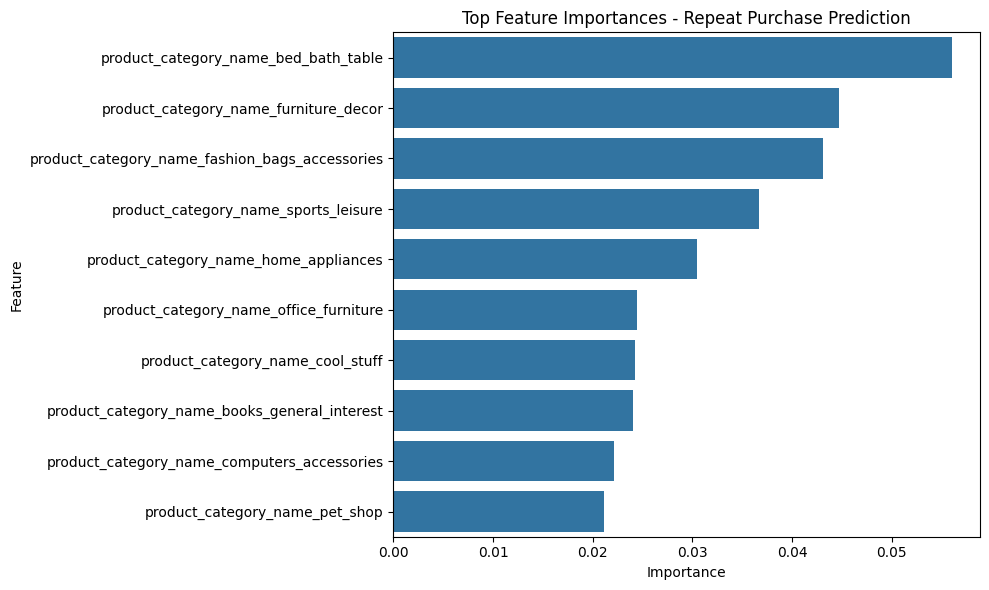

In [17]:
print(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top Feature Importances - Repeat Purchase Prediction')
plt.tight_layout()
plt.show()